# Training a regression model on California housing data to predict the median of the house value based on its traits

note: the usual accuracy for this data is ~55000 rmse

## 1| Loading the dataset
we will start by loading the dataset and viewing its content

In [1]:
import pandas as pd
housing_df = pd.read_csv("housing.csv")
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
housing_df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [3]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
housing_df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## 2| Data imputation

In [5]:
import warnings
warnings.filterwarnings('ignore')

# fill the missing number of bedrooms by the mode of the observations with the same number of total rooms
housing_df["total_bedrooms"] = housing_df["total_bedrooms"].fillna(
    housing_df.groupby("total_rooms")["total_bedrooms"]
    .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

In [6]:
housing_df.isnull().sum()

longitude              0
latitude               0
housing_median_age     0
total_rooms            0
total_bedrooms        15
population             0
households             0
median_income          0
median_house_value     0
ocean_proximity        0
dtype: int64

In [7]:
# drop the records that dont have simmilar total rooms with the rest of the data 
housing_df.dropna(inplace=True)
housing_df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [8]:
housing_df.shape

(20625, 10)

## 3| Exploratory data analysis and dealing with outliers

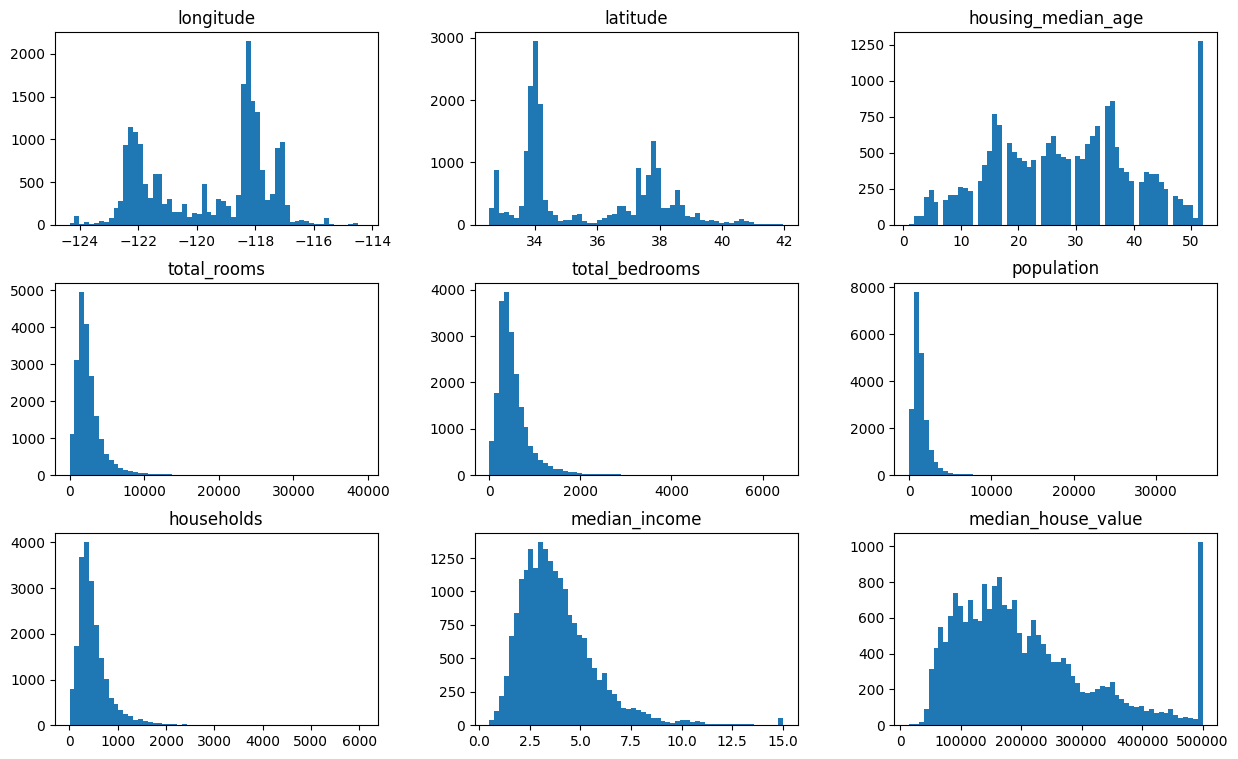

In [9]:
import matplotlib.pyplot as plt
housing_df.hist(bins=60, figsize=(15,9), grid=False)
plt.show()

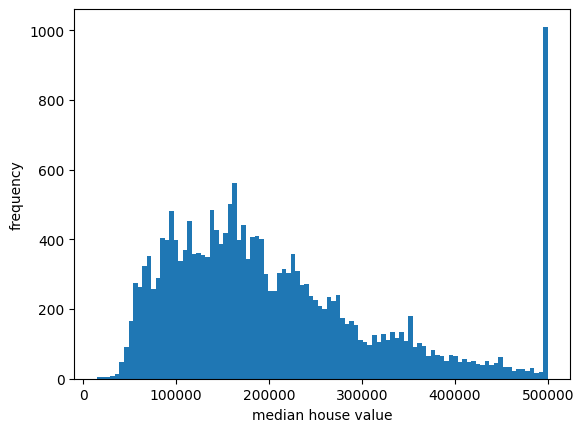

In [10]:
plt.hist(housing_df["median_house_value"], bins = 100)
plt.xlabel("median house value")
plt.ylabel("frequency")
plt.show()

In [11]:
# from the graph it seems like the data is being capped at 500000
# which created data inconsistency at median_house_value = 500000
housing_df = housing_df[housing_df["median_house_value"] < 500001]
housing_df.shape

(19661, 10)

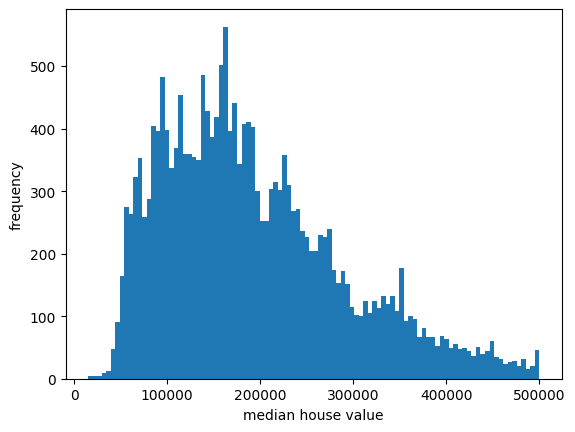

In [12]:
plt.hist(housing_df["median_house_value"], bins = 100)
plt.xlabel("median house value")
plt.ylabel("frequency")
plt.show()

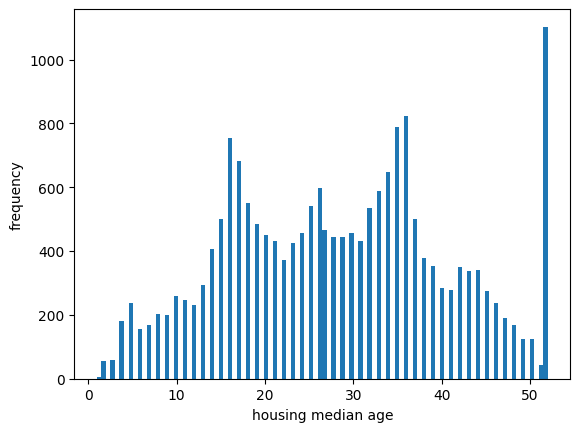

In [13]:
plt.hist(housing_df["housing_median_age"], bins = 100)
plt.xlabel("housing median age")
plt.ylabel("frequency")
plt.show()

In [14]:
# same thing happens in housing_median_age at 51
# it also seems like it has a lot of inconsistency with the entire set
housing_df = housing_df[housing_df["housing_median_age"] < 52]
housing_df.shape

(18558, 10)

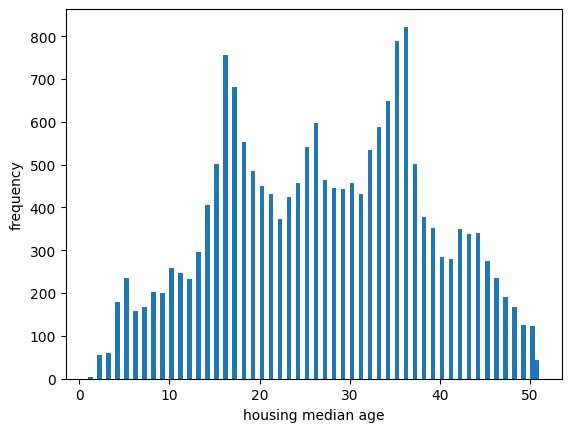

In [15]:
plt.hist(housing_df["housing_median_age"], bins = 100)
plt.xlabel("housing median age")
plt.ylabel("frequency")
plt.show()

In [16]:
housing_df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     8322
INLAND        6340
NEAR OCEAN    2328
NEAR BAY      1566
ISLAND           2
Name: count, dtype: int64

In [17]:
# we dont have many observation with ISLAND houses that will make the model overfit it and will not learn any patterns
housing_df = housing_df[housing_df["ocean_proximity"] != "ISLAND"]
housing_df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     8322
INLAND        6340
NEAR OCEAN    2328
NEAR BAY      1566
Name: count, dtype: int64

## 4| Feature engineering and dealing with categorical data

In [18]:
housing_df = pd.get_dummies(housing_df, columns=["ocean_proximity"])
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,False,False,True,False
15,-122.26,37.85,50.0,1120.0,283.0,697.0,264.0,2.1250,140000.0,False,False,True,False
18,-122.26,37.84,50.0,2239.0,455.0,990.0,419.0,1.9911,158700.0,False,False,True,False


In [19]:
import numpy as np
center_lon = housing_df["longitude"].mean()
center_lat = housing_df["latitude"].mean()
housing_df["distance_to_center"] = np.sqrt((housing_df["longitude"] - center_lon)**2 + (housing_df["latitude"] - center_lat)**2)
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,distance_to_center
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False,3.571924
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False,3.551451
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,False,False,True,False,3.569722
15,-122.26,37.85,50.0,1120.0,283.0,697.0,264.0,2.1250,140000.0,False,False,True,False,3.576023
18,-122.26,37.84,50.0,2239.0,455.0,990.0,419.0,1.9911,158700.0,False,False,True,False,3.569722


In [20]:
housing_df["bedroom_per_room"] = housing_df["total_bedrooms"] / housing_df["total_rooms"]
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,distance_to_center,bedroom_per_room
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False,3.571924,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False,3.551451,0.155797
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,False,False,True,False,3.569722,0.260274
15,-122.26,37.85,50.0,1120.0,283.0,697.0,264.0,2.1250,140000.0,False,False,True,False,3.576023,0.252679
18,-122.26,37.84,50.0,2239.0,455.0,990.0,419.0,1.9911,158700.0,False,False,True,False,3.569722,0.203216


## 5| Creating a pipeline to train different models on the data

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [22]:
# split our data into training and testing set
X = housing_df.drop("median_house_value", axis=1)
y = housing_df["median_house_value"]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

In [23]:
pipeline = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])

In [24]:
param_grid = [
    {
        "model" : [LinearRegression()]
    },{
        "model" : [Lasso()],
        "model__alpha" : [0.001, 0.01, 0.1, 1]
    }, {
        "model" : [Ridge()],
        "model__alpha" : [0.001, 0.01, 0.1, 1]
    }, {
        "model" : [SVR()],
        "model__kernel" : ['linear', 'rbf'],
        "model__C" : [10, 100, 1000, 10000],
        "model__epsilon" : [0.001, 0.01, 0.1]
    }, {
        "model" : [RandomForestRegressor(random_state=67)],
        "model__n_estimators" : [200],
        "model__max_depth" : [10, 20],
        "model__min_samples_split" : [60, 80],
        "model__min_samples_leaf": [30, 40]
    }
]

In [25]:
# creating 6 fold cross validation
cv = KFold(
    n_splits=6,
    shuffle=True,
    random_state=67
)

In [26]:
grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=cv, scoring="neg_root_mean_squared_error",return_train_score = True, verbose=1, n_jobs=-1)

## 6| Train the models

In [27]:
grid_search.fit(x_train, y_train)

Fitting 6 folds for each of 41 candidates, totalling 246 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [LinearRegression()]}, {'model': [Lasso()], 'model__alpha': [0.001, 0.01, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time 

## 7| Explore and visualize the results

In [28]:
result_df = pd.DataFrame(grid_search.cv_results_)
def extract_model_name(params):
    name = str(params["model"]).split("(")[0]
    return name
result_df["model_name"] = result_df["params"].apply(extract_model_name)
result_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   mean_fit_time                   41 non-null     float64
 1   std_fit_time                    41 non-null     float64
 2   mean_score_time                 41 non-null     float64
 3   std_score_time                  41 non-null     float64
 4   param_model                     41 non-null     object 
 5   param_model__alpha              8 non-null      float64
 6   param_model__C                  24 non-null     float64
 7   param_model__epsilon            24 non-null     float64
 8   param_model__kernel             24 non-null     object 
 9   param_model__max_depth          8 non-null      float64
 10  param_model__min_samples_leaf   8 non-null      float64
 11  param_model__min_samples_split  8 non-null      float64
 12  param_model__n_estimators       8 non-

In [29]:
result_df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean_fit_time,41.0,15.922053,9.146207,0.097599,16.492946,18.031143,20.764412,37.169626
std_fit_time,41.0,2.074117,1.819420,0.019640,0.705860,2.050249,3.088453,8.375583
mean_score_time,41.0,2.499696,2.876153,0.010612,0.112488,1.570319,5.888858,8.955149
std_score_time,41.0,0.333037,0.358489,0.001771,0.016315,0.261400,0.544079,1.343889
param_model__alpha,8.0,0.277750,0.447699,0.001000,0.007750,0.055000,0.325000,1.000000
param_model__C,24.0,2777.500000,4277.913195,10.000000,77.500000,550.000000,3250.000000,10000.000000
param_model__epsilon,24.0,0.037000,0.045660,0.001000,0.001000,0.010000,0.100000,0.100000
param_model__max_depth,8.0,15.000000,5.345225,10.000000,10.000000,15.000000,20.000000,20.000000
param_model__min_samples_leaf,8.0,35.000000,5.345225,30.000000,30.000000,35.000000,40.000000,40.000000
param_model__min_samples_split,8.0,70.000000,10.690450,60.000000,60.000000,70.000000,80.000000,80.000000


In [30]:
def create_label(row):
    model = row['model_name']
    rank = row['rank_test_score']
    params = row['params']
    
    # Extract key hyperparameters
    if model == 'LinearRegression':
        return f"Rank {rank}\n{model}"
    elif model == 'Lasso':
        alpha = params.get('model__alpha', 'N/A')
        return f"Rank {rank}\n{model}\nα={alpha}"
    elif model == 'Ridge':
        alpha = params.get('model__alpha', 'N/A')
        return f"Rank {rank}\n{model}\nα={alpha}"
    elif model == 'SVR':
        C = params.get('model__C', 'N/A')
        eps = params.get('model__epsilon', 'N/A')
        kernel = params.get('model__kernel', 'N/A')
        return f"Rank {rank}\n{model}\nC={C}, ε={eps}, kernel={kernel}"
    elif model == 'RandomForestRegressor':
        depth = params.get('model__max_depth', 'N/A')
        min_split = params.get('model__min_samples_split', 'N/A')
        min_leaf = params.get('model__min_samples_leaf', 'N/A')
        return f"Rank {rank}\n{model}\nd={depth}, split={min_split}, leaf={min_leaf}"
    return f"Rank {rank}\n{model}"

result_df["label"] = result_df.apply(create_label, axis=1)

result_df["mean_test_rmse"] = -result_df["mean_test_score"]
result_df["mean_train_rmse"] = -result_df["mean_train_score"]

result_sorted = result_df.sort_values('rank_test_score')

### plot 1: all models against their scores

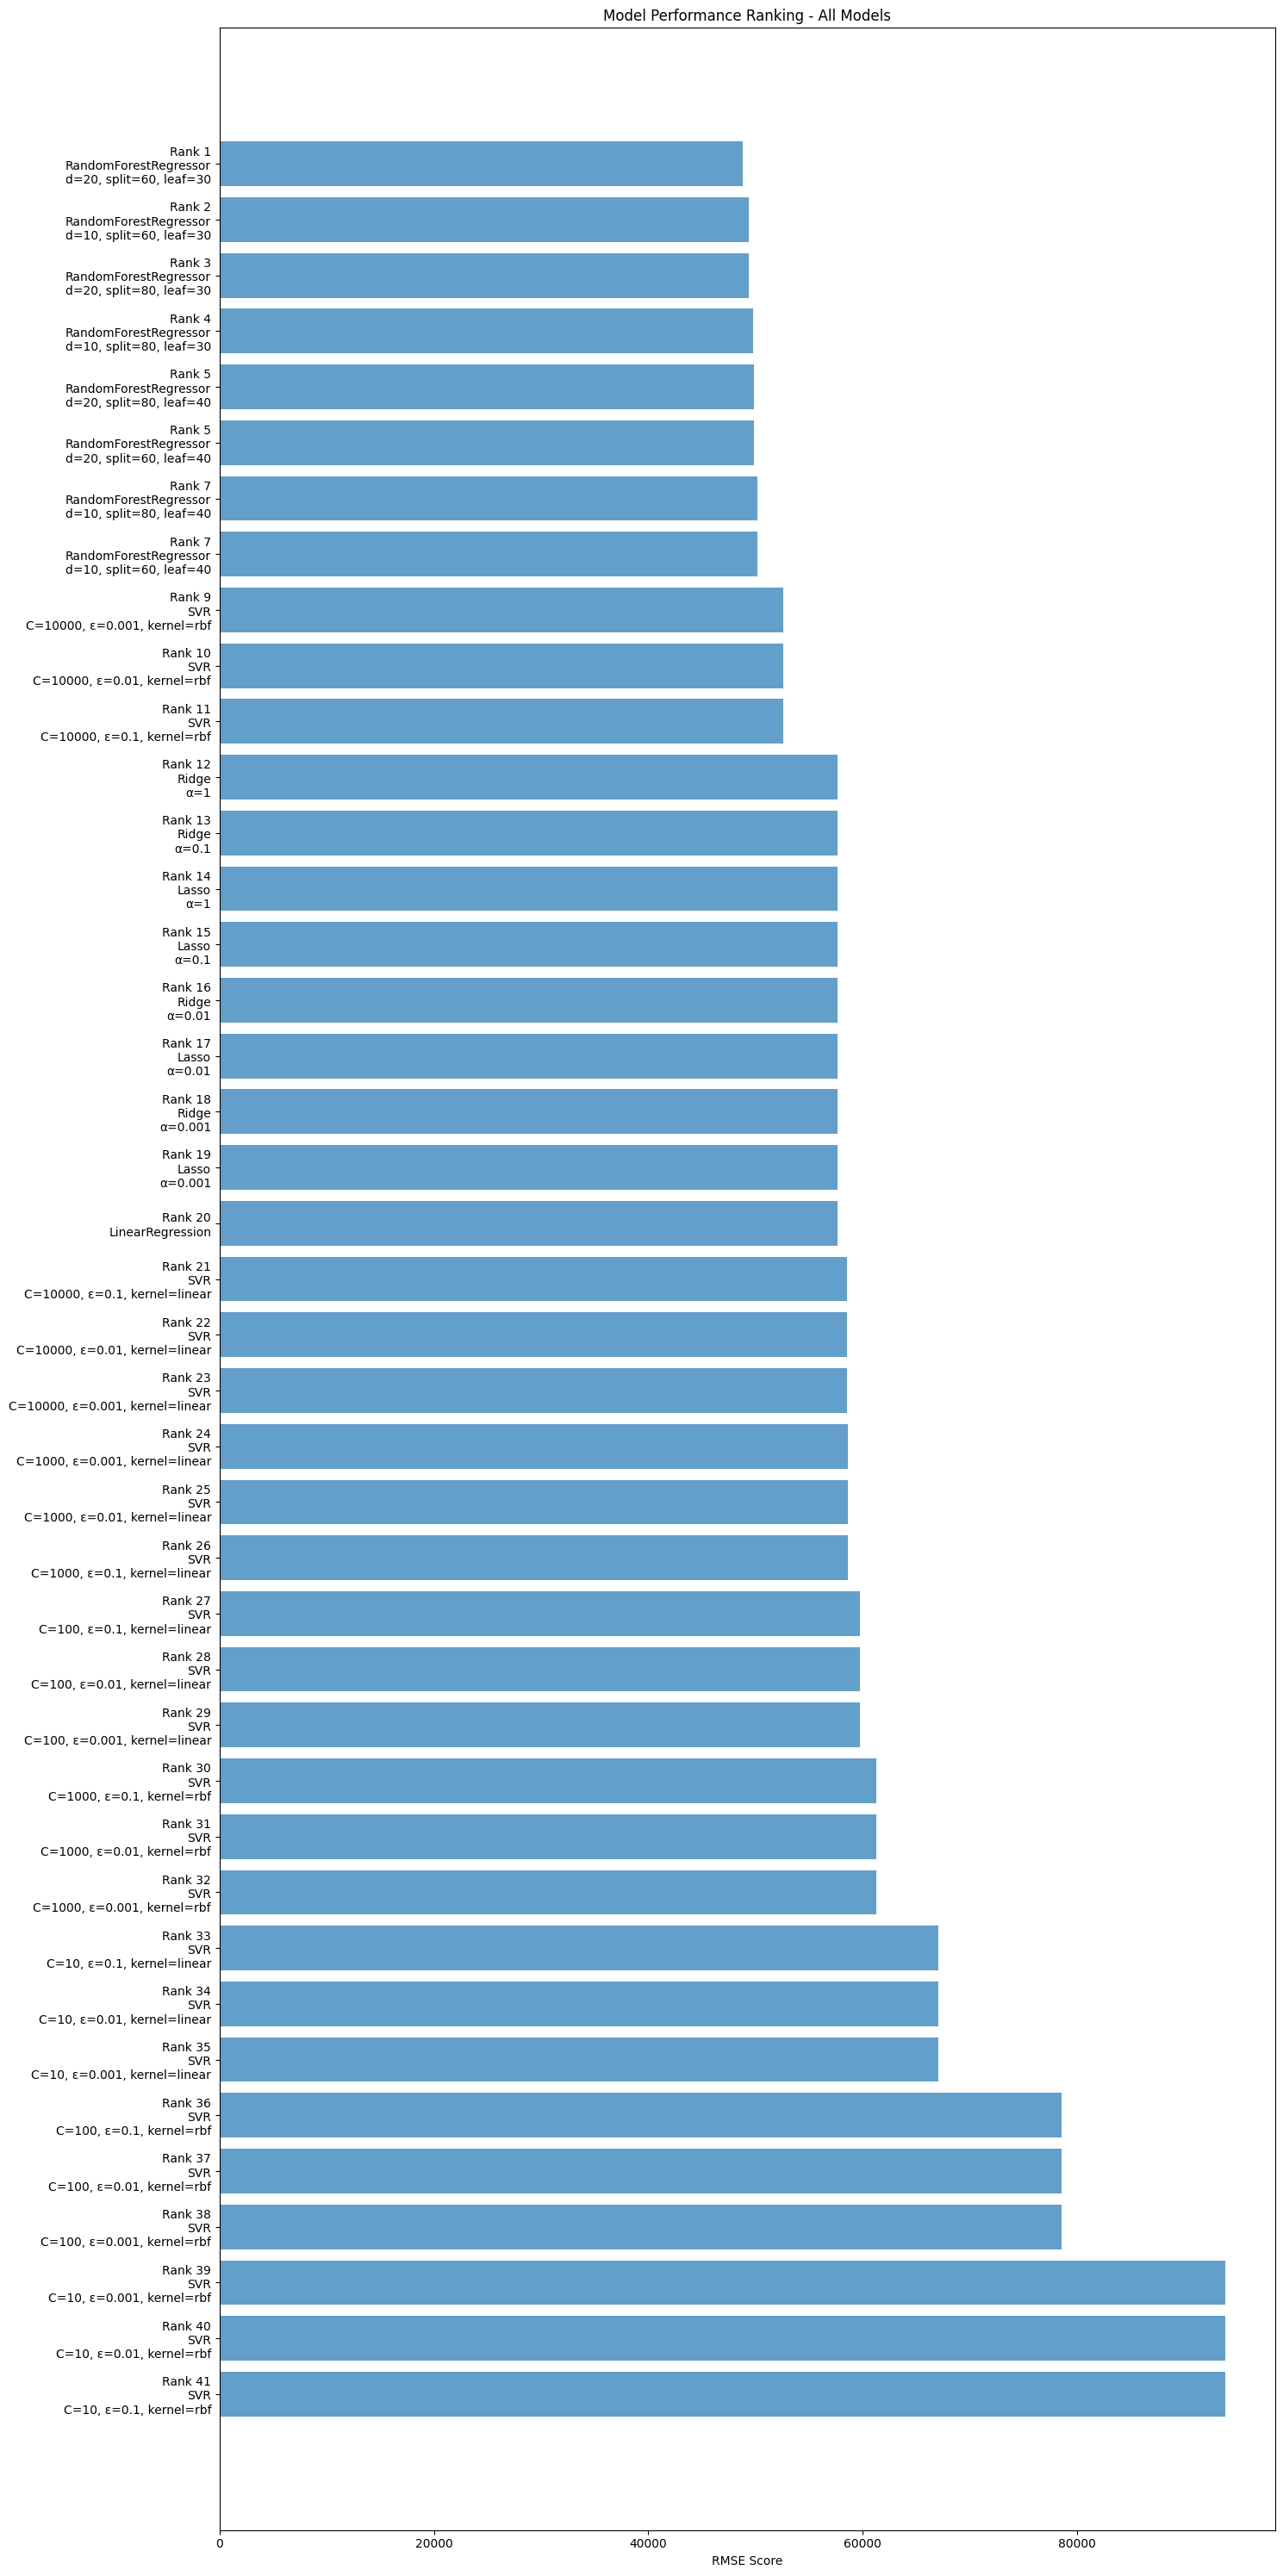

In [31]:
fig, ax = plt.subplots(figsize=(15, 30))
y_pos = np.arange(len(result_sorted["label"]))
ax.barh(y_pos, result_sorted['mean_test_rmse'], alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(result_sorted["label"])
ax.set_xlabel('RMSE Score')
ax.set_title('Model Performance Ranking - All Models')
ax.invert_yaxis()  # Best model at top
plt.tight_layout()
plt.savefig('all_models_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

### plot 2: top 6 models(based on validation score) (train vs  validation)

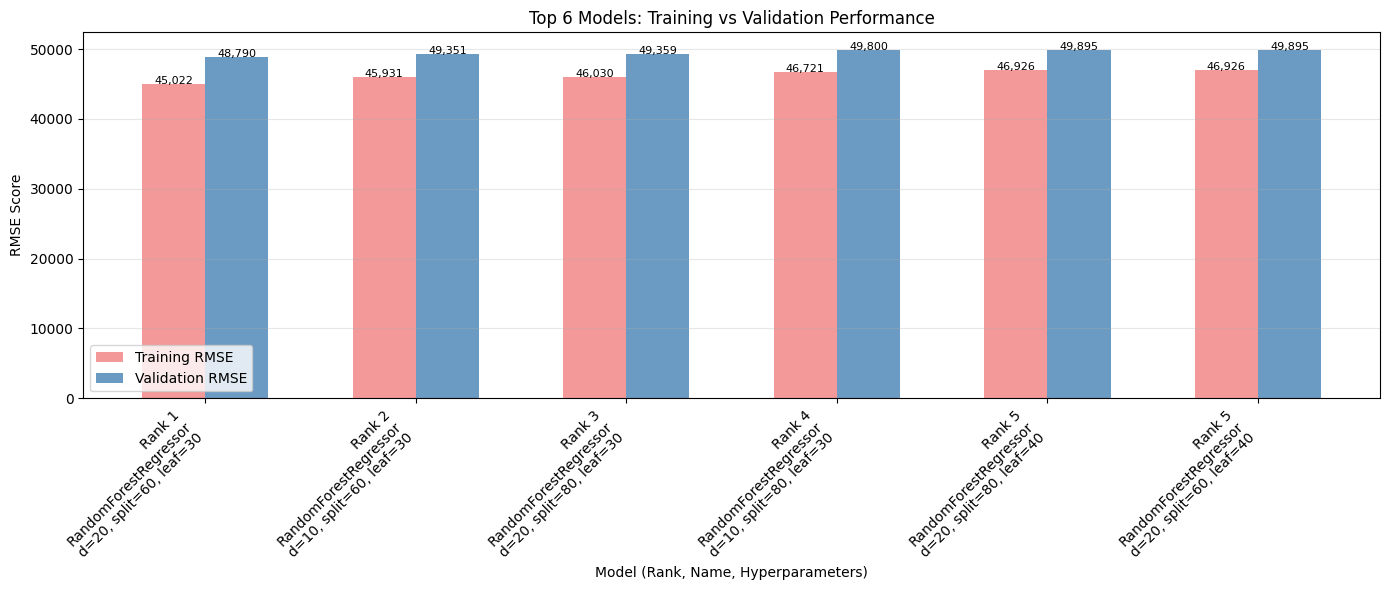

In [32]:
fig2, ax2 = plt.subplots(figsize=(14, 6))

# Get top 6 models
top6 = result_sorted[0:6]

x = np.arange(len(top6))
width = 0.3

bars1 = ax2.bar(x - width/2, top6['mean_train_rmse'], width, label='Training RMSE', color='lightcoral', alpha=0.8)
bars2 = ax2.bar(x + width/2, top6['mean_test_rmse'], width, label='Validation RMSE', color='steelblue', alpha=0.8)

ax2.set_xlabel('Model (Rank, Name, Hyperparameters)')
ax2.set_ylabel('RMSE Score')
ax2.set_title('Top 6 Models: Training vs Validation Performance')
ax2.set_xticks(x)
ax2.set_xticklabels(top6['label'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('top6_models.png', dpi=300, bbox_inches='tight')
plt.show()

### plot 3: performance distribution by model type

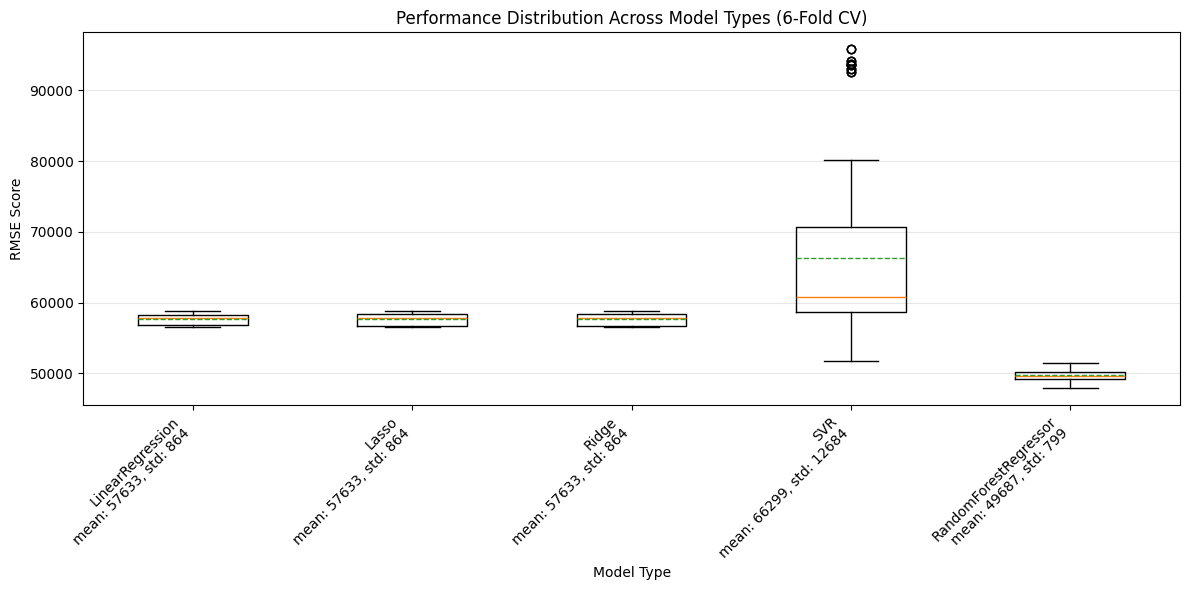

In [33]:
fig3, ax3 = plt.subplots(figsize=(12, 6))

# Group all test scores by model type
model_types = result_df['model_name'].unique()
box_data = []
labels_box = []

for model in model_types:
    model_data = result_df[result_df['model_name'] == model]
    # Collect all cross-validation scores for this model type
    scores = []
    for _, row in model_data.iterrows():
        for i in range(6):  # 6-fold CV
            score = -row[f'split{i}_test_score']
            scores.append(score)
    box_data.append(scores)
    labels_box.append(f"{model}\nmean: {int(np.mean(scores))}, std: {int(np.std(scores))}")

ax3.boxplot(box_data, labels=labels_box, showmeans=True, meanline=True)
ax3.set_xlabel('Model Type')
ax3.set_ylabel('RMSE Score')
ax3.set_title('Performance Distribution Across Model Types (6-Fold CV)')
ax3.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('models_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
from sklearn.metrics import mean_squared_error
training_score = - float(result_sorted[0:1]["mean_train_score"])
cv_score = - grid_search.best_score_
testing_score = np.sqrt(mean_squared_error(y_test, grid_search.predict(x_test)))
print(f"Training RMSE:         {training_score}")
print(f"Cross validation RMSE: {cv_score}")
print(f"Testing RMSE:          {testing_score}")

Training RMSE:         45022.14017878788
Cross validation RMSE: 48790.31106445615
Testing RMSE:          50497.34103762466


the difference between the training score and the test and validation score are not big which indicate a well generalized model

### 8| Saving the best model

In [35]:
best_model = grid_search.best_estimator_

import joblib
joblib.dump(best_model, "Housing_estimator_model.pkl")

model_info = {"best_params" : grid_search.best_params_, "training_rmse" : training_score, "cv_rmse" : cv_score, "test_rmse" : testing_score}
joblib.dump(model_info, "model_info.pkl")

['model_info.pkl']